In [1]:
import numpy as np
from pyscf import gto, scf, mcscf, ao2mo
from qchem.utils import  (
    MoleculeData,
    get_hf_gse_from_mol,
    one_electron_integral_transform,
    two_electron_integral_transform,
    DMDMWorkflow,
    CalculationMode
    )

from dmdm.interface import DMDM
import qrunch as qc


qc.register_license_file("/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/license_fm.txt")

/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/core/public_api.py:254: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  module = cast(_ImportCallable, _original_import)(name, globals, locals, fromlist, level)
/home/flemming/Nextcloud/Cherimoya/training/master_cs/ms_project/code/qchem/src/qchem/utils.py:10: UserWarning: The module 'qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator' is not part of the public API of 'qrunch'. Its interface may change without notice.
The module was imported from qchem.utils.
  from qrunch.chemistry.reduced_density_matrices.reduced_density_matrix_calculator import ReducedDensityMatrixCalculator
/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/qrunch/common/register_license.py:125: UserWarning: A license file already exists at user config path /home/flemming/.local/share/qrunch/license.txt. Will NOT

converged SCF energy = -7.98415735686112

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -7.98418910708921  E(CI) = -8.97950674518326  S^2 = 0.0000000
CASCI state   1  E = -7.81495914411151  E(CI) = -8.81027678220555  S^2 = 2.0000000
CASCI state   2  E = -7.81076154155869  E(CI) = -8.80607917965274  S^2 = 0.0000000
CASCI state   3  E = -7.75118724651257  E(CI) = -8.74650488460662  S^2 = 2.0000000
CASCI state   4  E = -7.75052895201310  E(CI) = -8.74584659010714  S^2 = 0.0000000
idx, max(abs(grad active)): 16 2.2898349882893854e-16
Smallest Hessian eigenvalue: (0.17108111127901898+0j)
Smallest diagonal element in the metric: 0.9999079905727485
converged SCF energy = -7.98415735686111
E(RMP2) = -8.0117371804902  E_corr = -0.0275798236290935
E(SCS-RMP2) = -8.01716359885469  E_corr = -0.0330062419935769
CASSCF energy = -7.88432195351032
CASCI E = -7.88432195351032  E(CI) = -8.8796395916

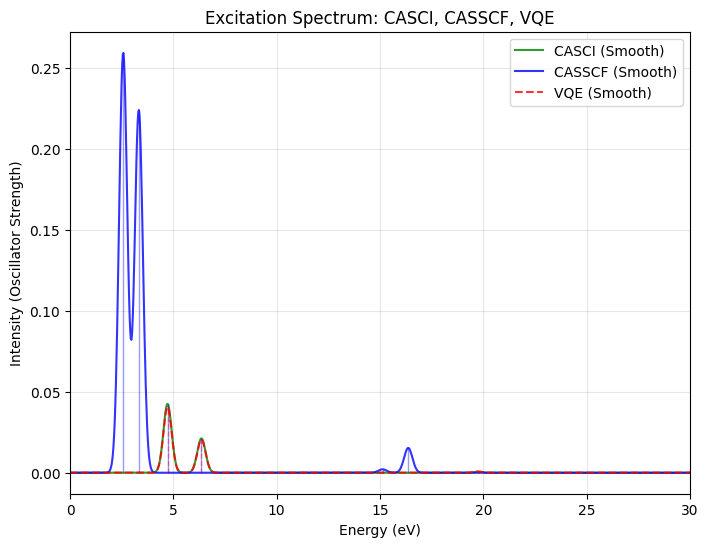

{'casci': {'exc_energies_ev': array([ 0.        ,  4.71920686,  6.35822269, 19.7485486 , 20.91263134]),
  'oscillator_strengths': array([0.00000000e+00, 4.25824500e-02, 2.12153724e-02, 6.38627819e-04,
         4.34611001e-05]),
  'total_energies': array([-7.98418911, -7.81495914, -7.81076154, -7.75118725, -7.75052895]),
  'e_cas': array([-8.97950675, -8.81027678, -8.80607918, -8.74650488, -8.74584659]),
  'dmdm_obj': <dmdm.interface.DMDM at 0x7f1e64622010>},
 'casscf': {'exc_energies_ev': array([ 0.        ,  2.57271682,  3.32625923, 15.12242769, 16.36513153]),
  'oscillator_strengths': array([0.        , 0.25951217, 0.22409357, 0.00211813, 0.01534471]),
  'total_energies': array([-7.96250197, -7.89396305, -7.86795873, -7.85691897, -7.84026704]),
  'e_cas': np.float64(-8.879639591604363),
  'dmdm_obj': <dmdm.interface.DMDM at 0x7f1e64712e90>},
 'vqe': {'exc_energies_ev': array([ 0.        ,  4.71919116,  6.35821785, 19.74857791, 20.91262758]),
  'oscillator_strengths': array([0.0000000

In [4]:
benzene_molecule = [
    ('C',  1.396,  0.000,  0.000),
    ('C',  0.698,  1.209,  0.000),
    ('C', -0.698,  1.209,  0.000),
    ('C', -1.396,  0.000,  0.000),
    ('C', -0.698, -1.209,  0.000),
    ('C',  0.698, -1.209,  0.000),
    ('H',  2.483,  0.000,  0.000),
    ('H',  1.242,  2.151,  0.000),
    ('H', -1.242,  2.151,  0.000),
    ('H', -2.483,  0.000,  0.000),
    ('H', -1.242, -2.151,  0.000),
    ('H',  1.242, -2.151,  0.000),
]


# workflow = DMDMWorkflow(
#     basis='sto-3g',
#     molecule=benzene_molecule,
#     num_active_orbitals=6,
#     num_active_electrons=6,
#     num_states=6,
#     mode=CalculationMode.BOTH,
#     vqe_max_iterations=1000,
#     verbose=1
# )

h2o = [
        ["O", (0.0, 0.0, 0.0)],  # Oxygen at origin
        ["H", (0.0, 0.757, 0.587)],  # Hydrogen 1
        ["H", (0.0, -0.757, 0.587)],  # Hydrogen 2
    ]


# Simple H2O example

workflow = DMDMWorkflow(
    basis="aug-cc-pVDZ",
    molecule=MoleculeData.molecules["LiH"]["coords"], # String key for qchem MoleculeData
    # molecule=h2o,
    num_active_orbitals=4,
    num_active_electrons=4,
    num_states=5,
    mode=CalculationMode.BOTH,
    vqe_max_iterations=500
)

# VQE only
# workflow.run_quantum_vqe()


# workflow.run_classical_casscf()

# Runs both, then plots comparison
workflow.run_comparison(plot=True)
# workflow.run_quantum_vqe()
# workflow.plot_spectrum(show_vqe=True, show_casci=False)

converged SCF energy = -7.73464947729185

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -7.73466410184423  E(CI) = -9.72529937803232  S^2 = 0.0000000
CASCI state   1  E = -7.55318395574544  E(CI) = -9.54381923193353  S^2 = 2.0000000
CASCI state   2  E = -7.54998303114131  E(CI) = -9.54061830732940  S^2 = 0.0000000
CASCI state   3  E = -7.48860860799571  E(CI) = -9.47924388418379  S^2 = 2.0000000
CASCI state   4  E = -7.48803644050147  E(CI) = -9.47867171668956  S^2 = 0.0000000
idx, max(abs(grad active)): 16 6.938893903907228e-16
Smallest Hessian eigenvalue: (0.1830920695115926+0j)
Smallest diagonal element in the metric: 0.9999625100061821
converged SCF energy = -7.8776293972477

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -7.87764186993474  E(CI) = -9.48120917575292  S^2 = 0

/home/flemming/micromamba/envs/qrunch/lib/python3.11/site-packages/dmdm/interface.py:908: RuntimeWarning: invalid value encountered in scalar multiply
  2


converged SCF energy = -7.83999710524176

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -7.87632006863479  E(CI) = -8.18015387394771  S^2 = 2.0000000
CASCI state   1  E = -7.87573873213203  E(CI) = -8.17957253744494  S^2 = 0.0000000
CASCI state   2  E = -7.82471278696198  E(CI) = -8.12854659227490  S^2 = 0.0000000
CASCI state   3  E = -7.80240937308432  E(CI) = -8.10624317839724  S^2 = 2.0000000
CASCI state   4  E = -7.80136801885255  E(CI) = -8.10520182416547  S^2 = 0.0000000
idx, max(abs(grad active)): 0 1.27675647831893e-15
Smallest Hessian eigenvalue: (-4.369103149563905e-15+0j)
Smallest diagonal element in the metric: 8.326672684688675e-17
converged SCF energy = -7.83636043750805

WARN: Mulitple states found in CASCI solver. First state is used to compute the Fock matrix and natural orbitals in active space.

CASCI state   0  E = -7.87813502645746  E(CI) = -8.17117270670850  S

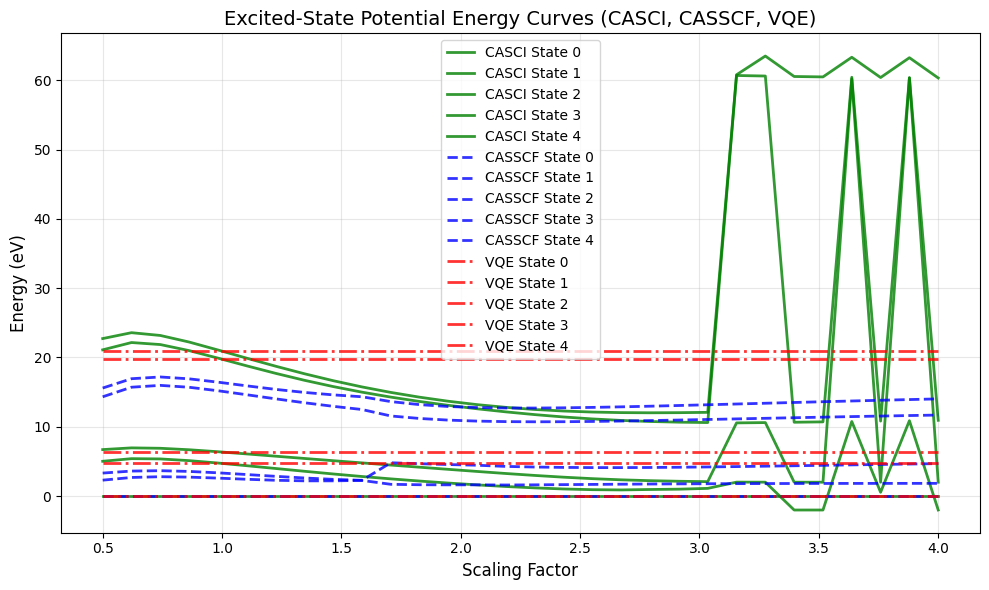

In [7]:
comparison = workflow.compare_pec_methods(
    scale_range=(0.5, 4.0),
    num_points=30,
    methods=['casci', 'casscf_average', 'vqe'],
    plot=True
)

In [3]:
print(workflow._casscf_results['exc_energies_ev'])
print(workflow._casscf_results['oscillator_strengths'])

[ 0.          4.89283664  5.2853512  15.78659429 17.88679625]
[0.         0.00019818 0.00442628 0.09330621 0.09917379]


converged SCF energy = -76.0390921843416
Error running CASCI: Multiple roots are detected in fcisolver.  CASSCF does not know which state to optimize.
See also  mcscf.state_average  or  mcscf.state_specific  for excited states.
  Inactive: 3, Active: 4, Virtual: 34
idx, max(abs(grad active)): 18 1.7349918362934147e-07
Smallest Hessian eigenvalue: (0.3593415630094464+0j)
Smallest diagonal element in the metric: 0.9999846709582745


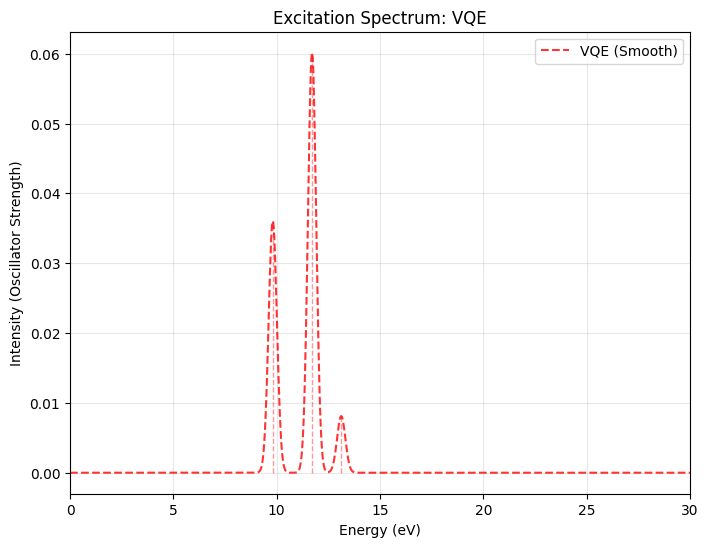

{'vqe': {'exc_energies_ev': array([ 0.        ,  9.80999771, 11.27246231, 11.71135649, 13.12180315]),
  'oscillator_strengths': array([0.00000000e+00, 3.60913566e-02, 8.19889513e-26, 6.01369766e-02,
         8.11688571e-03]),
  'dmdm_obj': <dmdm.interface.DMDM at 0x7f4a35880e10>}}

In [3]:
# Simple H2O example

workflow = DMDMWorkflow(
    basis="aug-cc-pVDZ",
    molecule=MoleculeData.molecules["H2O"]["coords"], # String key for qchem MoleculeData
    num_active_orbitals=4,
    num_active_electrons=4,
    num_states=5,
    mode=CalculationMode.BOTH,
    vqe_max_iterations=1000
)

# VQE only
# workflow.run_quantum_vqe()

# Runs both, then plots comparison
workflow.run_comparison(plot=True)

In [ ]:
print("check abs difference: \n")
abs(workflow._casci_results["exc_energies_ev"] - workflow._vqe_results["exc_energies_ev"])